# **Convolutional Neural Networks**  
Reference Material:
1. MNIST Digit Dataset : http://yann.lecun.com/exdb/mnist/

2. CNN : https://towardsdatascience.com/a-guide-to-convolutional-neural-networks-from-scratch-f1e3bfc3e2de

3. CNN pytorch: https://www.kaggle.com/code/sdelecourt/cnn-with-pytorch-for-mnist

4. CNN pytorch: https://nextjournal.com/gkoehler/pytorch-mnist (The below code is taken from here.)

#**Problem 1** : Demonstrate Image Classification using CNNs on MNIST Handwritten Digit Recognition dataset
Observations to be demonstrated:
1. Show image classification using CNN.
2. Demonstrate the translation invariant property of pooling layer (can choose two images, from which one is translated and show the output of pooling layer is near to identical for both the images).
3. Show that CNN used fewer number of parameters.

In [1]:
import numpy as np
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Data Preparation

In [2]:
(x_train, y_train), (x_test, y_test)=tf.keras.datasets.mnist.load_data(path="mnist.npz")
print("Length of each letter" , len(x_train[0]))

print(x_train[0])
print(y_train[0])

Length of each letter 28
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 2

In [3]:
def select_data(cl,x_train, y_train,x_test, y_test,lab):
  id_tr=np.where(y_train==cl)
  id_te=np.where(y_test==cl)
  print(id_tr[0])
  tr_lab=y_train[id_tr[0]]
  tr_lab=np.tile(lab,tr_lab.shape)
  te_lab=y_test[id_te[0]]
  te_lab=np.tile(lab,te_lab.shape)
  tr_d=x_train[id_tr[0],:,:]
  te_d=x_test[id_te[0],:,:]
  tr_d = tr_d.astype('float32')
  tr_d /= 255
  te_d=te_d.astype('float32')
  te_d /=255
  return tr_d,te_d,tr_lab,te_lab



In [4]:
cl=[3,5]

# for class 1
tr_d1,te_d1,tr_lab1,te_lab1=select_data(cl[0],x_train, y_train,x_test, y_test,0)
# for class 2
tr_d2,te_d2,tr_lab2,te_lab2=select_data(cl[1],x_train, y_train,x_test, y_test,1)


data_tr=np.concatenate((tr_d1,tr_d2))
data_ts=np.concatenate((te_d1,te_d2))

lab_tr=np.concatenate((tr_lab1,tr_lab2))
lab_ts=np.concatenate((te_lab1,te_lab2))

[    7    10    12 ... 59978 59980 59996]
[    0    11    35 ... 59968 59993 59997]


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
from torch.utils.data import DataLoader

In [6]:
## data loader

class Dataset(Data.Dataset):
    def __init__(self, feat=None, label=None, context=None):
        super(Dataset, self).__init__()
        self.feat = feat
        self.label = label

    def __len__(self):
        leng=self.feat.shape[0]
        return int(leng)

    def __getitem__(self, index):
        #print(index)
        vector = self.feat[index,:,:]
        lab=np.asarray(self.label[index])
        #vector[-1] = self.classNum
        feat = torch.from_numpy(vector)
        label= torch.from_numpy(lab)
        return feat, label.float()


In [7]:
data_trn= Dataset(feat=data_tr,label=lab_tr)
train_loader = DataLoader(data_trn,shuffle=True, batch_size=64, pin_memory=True, num_workers=0)

data_tst = Dataset(feat=data_ts, label=lab_ts)
test_loader = DataLoader(data_tst,shuffle=True, batch_size=64, pin_memory=True, num_workers=0)

In [8]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([64, 28, 28])

## Taking two classes
 - Images of five: label 1
 - Images of three: label 0

 Note: You can take any other digits as well.

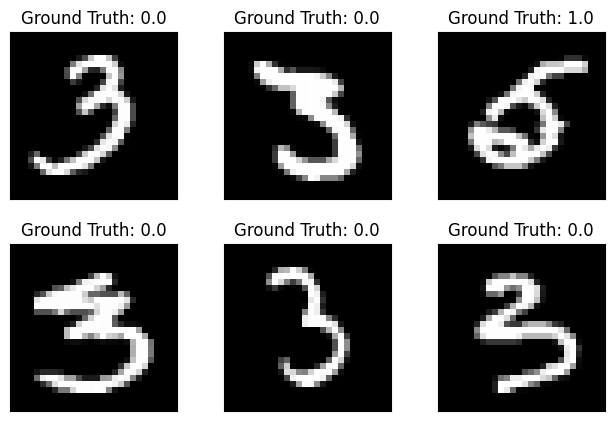

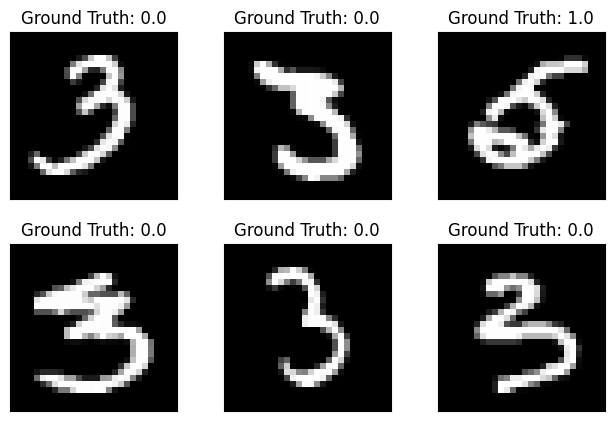

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure()

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

In [10]:
n_epochs = 10
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.01
momentum = 0.5
log_interval = 10

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

# **Two Class Classification**
Comparison between FFNN with one hidden layer and CNN with one convolution layer


# FFNN

In [11]:
# Write your code here to train FFNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

# Define the feed-forward neural network
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size) 
        self.sigmoid = nn.Sigmoid() 
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.out(x))
        return x


# Define the model parameters
input_size = data_tr.shape[1] * data_tr.shape[2]  # Flattened input size # 28 * 28
hidden_size = 90 
output_size = 2  # Binary classification (two classes)

# Instantiate the model, loss function, and optimizer
model_ffnn = FFNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
criterion = nn.CrossEntropyLoss()  # Cross Entropy loss for classification
optimizer = optim.Adam(model_ffnn.parameters(), lr=learning_rate)  # Adam optimizer

# Training loop
num_epochs = 30
running_losses = []
for epoch in range(num_epochs):
    model_ffnn.train()  # Set the model to training mode
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.view(-1, input_size)  # Flatten the inputs
        labels = labels.long()  # Ensure labels are in correct format
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_ffnn(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    running_losses.append(running_loss/len(train_loader))
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader)}")


correct = 0
total = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for inputs, labels in train_loader:
        inputs = inputs.view(-1, input_size)  # Flatten the inputs
        labels = labels.long()
        outputs = model_ffnn(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")
print(running_losses)

Epoch [1/30], Loss: 0.364664437527156
Epoch [2/30], Loss: 0.33557978931052906
Epoch [3/30], Loss: 0.32804847257571984
Epoch [4/30], Loss: 0.3262827488598903
Epoch [5/30], Loss: 0.3233416826356182
Epoch [6/30], Loss: 0.3222770185431064
Epoch [7/30], Loss: 0.3222124614438958
Epoch [8/30], Loss: 0.3207079596940984
Epoch [9/30], Loss: 0.31943329328990117
Epoch [10/30], Loss: 0.31885558663152197
Epoch [11/30], Loss: 0.31872229121666584
Epoch [12/30], Loss: 0.31911056245888136
Epoch [13/30], Loss: 0.3193350878868314
Epoch [14/30], Loss: 0.3173619954954853
Epoch [15/30], Loss: 0.31736925194935245
Epoch [16/30], Loss: 0.3169423275889613
Epoch [17/30], Loss: 0.31612979921188145
Epoch [18/30], Loss: 0.31628099413207883
Epoch [19/30], Loss: 0.31836357449299724
Epoch [20/30], Loss: 0.3167664810438841
Epoch [21/30], Loss: 0.3169913474696776
Epoch [22/30], Loss: 0.31617740982145237
Epoch [23/30], Loss: 0.3173004741168154
Epoch [24/30], Loss: 0.3153469312256871
Epoch [25/30], Loss: 0.3162140543289606

### Test result using FFNN

In [12]:
# Write your code here to test FFNN
# Evaluate the model on test data
model_ffnn.eval()  # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for inputs, labels in test_loader:
        inputs = inputs.view(-1, input_size)  # Flatten the inputs
        labels = labels.long()
        outputs = model_ffnn(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 99.00105152471083%


# CNN

In [13]:
# Write your code here to train CNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

# Define the CNN
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 10, kernel_size=3)  # 1 input channel, 10 output channels
        self.pool = nn.MaxPool2d(2, 2)

       # Fully connected layers
        # After Conv + Pool, the input size is reduced. Let's assume the input image size is 28x28 (like MNIST dataset).
        # Output size after conv1 with kernel size 3 is (28 - 3 + 1) = 26, then after pooling, it becomes 26 / 2 = 13.
        self.fc1 = nn.Linear(10 * 13 * 13, 50)  # Fully connected layer after flattening the feature maps
        self.fc2 = nn.Linear(50, 2)  # Output layer, assuming binary classification (output size = 2)
        
        

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Convolution + ReLU + MaxPooling
        x = x.view(-1, 10 * 13 * 13)  # Flatten for fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)  # Log softmax for output




### Training result using CNN

In [14]:
# Write your code here to test CNN
# Create the CNN model
model_cnn = CNN()

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross Entropy Loss for classification
optimizer = optim.Adam(model_cnn.parameters(), lr=learning_rate)  # Adam optimizer

# Training loop
num_epochs = 30
running_losses_cnn = []
for epoch in range(num_epochs):
    model_cnn.train()  # Set the model to training mode
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.unsqueeze(1)  # Add channel dimension (for grayscale image)
        labels = labels.long()        # Ensure labels are in the correct format
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_cnn(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    running_losses_cnn.append(running_loss/len(train_loader))

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader)}")

correct = 0
total = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for inputs, labels in train_loader:
        inputs = inputs.view(-1, input_size)  # Flatten the inputs
        labels = labels.long()
        outputs = model_ffnn(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")


Epoch [1/30], Loss: 0.15568257662472804
Epoch [2/30], Loss: 0.031784499713055046
Epoch [3/30], Loss: 0.021449578247413822
Epoch [4/30], Loss: 0.014089206648511023
Epoch [5/30], Loss: 0.011343768427786173
Epoch [6/30], Loss: 0.008148292027673951
Epoch [7/30], Loss: 0.00612367828850654
Epoch [8/30], Loss: 0.006838427693830293
Epoch [9/30], Loss: 0.002880005758460311
Epoch [10/30], Loss: 0.0023636133093095247
Epoch [11/30], Loss: 0.001025482460330202
Epoch [12/30], Loss: 0.0006084218986229543
Epoch [13/30], Loss: 0.0003342662253686944
Epoch [14/30], Loss: 0.0001551387250855481
Epoch [15/30], Loss: 0.00010885708790496472
Epoch [16/30], Loss: 0.00015137157723103573
Epoch [17/30], Loss: 9.883797322643301e-05
Epoch [18/30], Loss: 9.027393097211138e-05
Epoch [19/30], Loss: 8.486975411000894e-05
Epoch [20/30], Loss: 8.09365775627743e-05
Epoch [21/30], Loss: 7.765134352128717e-05
Epoch [22/30], Loss: 7.444735110147315e-05
Epoch [23/30], Loss: 7.136647356130677e-05
Epoch [24/30], Loss: 6.86350861

[0.364664437527156, 0.33557978931052906, 0.32804847257571984, 0.3262827488598903, 0.3233416826356182, 0.3222770185431064, 0.3222124614438958, 0.3207079596940984, 0.31943329328990117, 0.31885558663152197, 0.31872229121666584, 0.31911056245888136, 0.3193350878868314, 0.3173619954954853, 0.31736925194935245, 0.3169423275889613, 0.31612979921188145, 0.31628099413207883, 0.31836357449299724, 0.3167664810438841, 0.3169913474696776, 0.31617740982145237, 0.3173004741168154, 0.3153469312256871, 0.3162140543289606, 0.3154630539166993, 0.3179273712371594, 0.31494755227921417, 0.31670228058461986, 0.3166232848365004]
[0.15568257662472804, 0.031784499713055046, 0.021449578247413822, 0.014089206648511023, 0.011343768427786173, 0.008148292027673951, 0.00612367828850654, 0.006838427693830293, 0.002880005758460311, 0.0023636133093095247, 0.001025482460330202, 0.0006084218986229543, 0.0003342662253686944, 0.0001551387250855481, 0.00010885708790496472, 0.00015137157723103573, 9.883797322643301e-05, 9.027

Text(0.5, 0, 'Epoch')

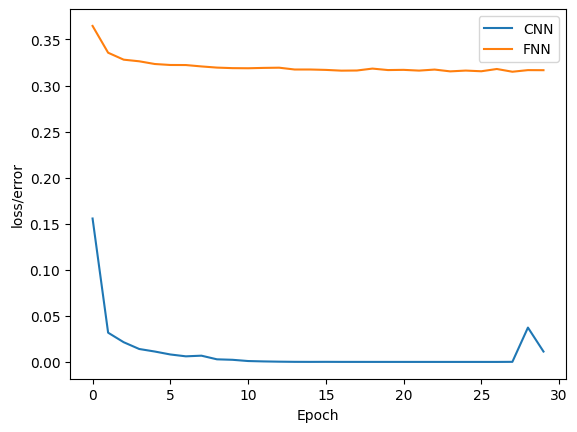

In [15]:
# Graph it out!
print(running_losses)
print(running_losses_cnn)
plt.plot(range(num_epochs), running_losses_cnn, label="CNN")
plt.plot(range(num_epochs), running_losses, label = "FNN")
plt.legend()
plt.ylabel("loss/error")
plt.xlabel('Epoch')

### Testing result using CNN

In [16]:
# Evaluate the model on test data
model_cnn.eval()  # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for inputs, labels in test_loader:
        inputs = inputs.unsqueeze(1)  # Add channel dimension (for grayscale image)
        labels = labels.long()
        outputs = model_cnn(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 99.36908517350157%


# T-SNE plot obtained from output of hidden layers
This is to check how well both networks have learnt the distribution

### FFNN

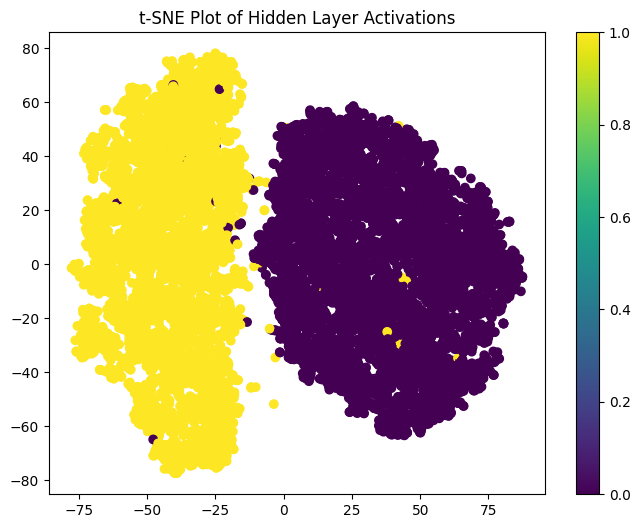

In [17]:
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Collect the activations from the hidden layer (or you can change this to the output layer)
def get_activations(model, dataloader):
    model.eval()  # Set model to evaluation mode
    activations = []
    labels_list = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.view(-1, input_size)  # Flatten the inputs
            labels = labels.long()
            
            # Forward pass through the network to get hidden activations
            hidden_activation = model.fc1(inputs)
            
            activations.append(hidden_activation)
            labels_list.append(labels)
    
    # Convert activations and labels to a single tensor
    activations = torch.cat(activations, dim=0).cpu().numpy()
    labels_list = torch.cat(labels_list, dim=0).cpu().numpy()
    
    return activations, labels_list

# Get activations from the hidden layer
activations, labels_list = get_activations(model_ffnn, train_loader)

# Apply t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
activations_2d = tsne.fit_transform(activations)

# Create a scatter plot for the t-SNE reduced activations
plt.figure(figsize=(8, 6))
plt.scatter(activations_2d[:, 0], activations_2d[:, 1], c=labels_list, cmap='viridis', marker='o')
plt.colorbar()
plt.title("t-SNE Plot of Hidden Layer Activations")
plt.show()


### CNN

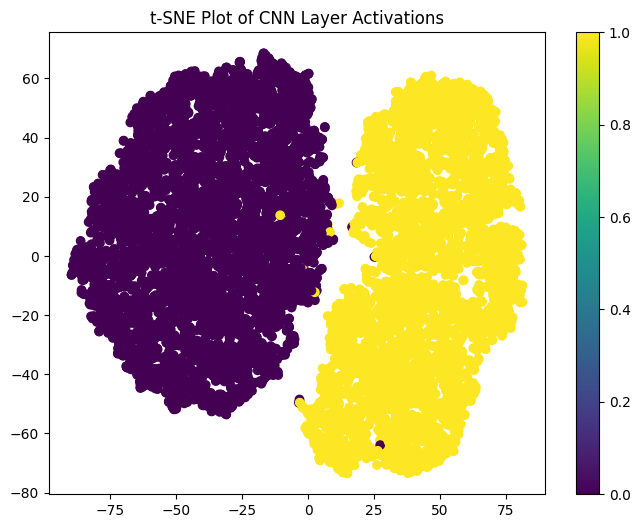

In [18]:
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Function to extract activations from the CNN model
def get_cnn_activations(model, dataloader):
    model.eval()  # Set model to evaluation mode
    activations = []
    labels_list = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.unsqueeze(1)  # Add channel dimension for grayscale images
            labels = labels.long()
            
            # Forward pass to get activations from fc1
            x = model.pool(F.relu(model.conv1(inputs)))  # Pass through convolutional layer and pool
            x = x.view(-1, 10 * 13 * 13)  # Flatten the output from conv layer
            hidden_activation = model.fc1(x)  # Get activations from fully connected layer fc1
            
            activations.append(hidden_activation)
            labels_list.append(labels)
    
    # Convert activations and labels to a single tensor
    activations = torch.cat(activations, dim=0).cpu().numpy()
    labels_list = torch.cat(labels_list, dim=0).cpu().numpy()
    
    return activations, labels_list

# Get activations from the CNN's fc1 layer
cnn_activations, cnn_labels = get_cnn_activations(model_cnn, train_loader)

# Apply t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
cnn_activations_2d = tsne.fit_transform(cnn_activations)

# Create a scatter plot for the t-SNE reduced activations
plt.figure(figsize=(8, 6))
plt.scatter(cnn_activations_2d[:, 0], cnn_activations_2d[:, 1], c=cnn_labels, cmap='viridis', marker='o')
plt.colorbar()
plt.title("t-SNE Plot of CNN Layer Activations")
plt.show()


### **Testing both networks on translated test set**

In [19]:
# Function to translate images by a certain number of pixels (shifts)
def translate_images(data, shift_x, shift_y):
    translated_data = torch.roll(data, shifts=(shift_x, shift_y), dims=(1, 2))
    return translated_data

# Translate the test set (shift by 2 pixels in both directions)
translated_test_data = translate_images(example_data, shift_x=2, shift_y=2)

In [20]:
# Test FFNN on Translated Test Set
def translated_ffnn(model, translated_data, target):
    model.eval()
    correct = 0
    with torch.no_grad():
        data = translated_data.view(-1, 28*28)  # Flatten the input
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

    accuracy = correct / len(target)
    print(f"FFNN Accuracy on Translated Test Set: {accuracy * 100:.2f}%")
    
# FFNN testing on translated data
translated_ffnn(model_ffnn, translated_test_data, example_targets)

FFNN Accuracy on Translated Test Set: 78.12%


In [21]:
# Test CNN on Translated Test Set
def translated_cnn(model, translated_data, target):
    model.eval()
    correct = 0
    with torch.no_grad():
        data = translated_data.unsqueeze(1)  # Add channel dimension (1 channel for grayscale images)
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

    accuracy = correct / len(target)
    print(f"CNN Accuracy on Translated Test Set: {accuracy * 100:.2f}%")


# CNN testing on translated data
translated_cnn(model_cnn, translated_test_data, example_targets)


CNN Accuracy on Translated Test Set: 87.50%


# **For 10 classes**

In [22]:
import torchvision
n_epochs = 10
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.01
momentum = 0.5
log_interval = 10

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

In [23]:
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/Users/ghs6kor/Library/CloudStorage/OneDrive-BoschGroup/Study/PhD/DeepLearning/Labs/Lab5', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,)) # The values 0.1307 and 0.3081 used for the Normalize() transformation below are the global mean and standard deviation of the MNIST dataset
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/Users/ghs6kor/Library/CloudStorage/OneDrive-BoschGroup/Study/PhD/DeepLearning/Labs/Lab5', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,)) # The values 0.1307 and 0.3081 used for the Normalize() transformation below are the global mean and standard deviation of the MNIST dataset
                             ])),
  batch_size=batch_size_test, shuffle=True)

In [24]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([1000, 1, 28, 28])

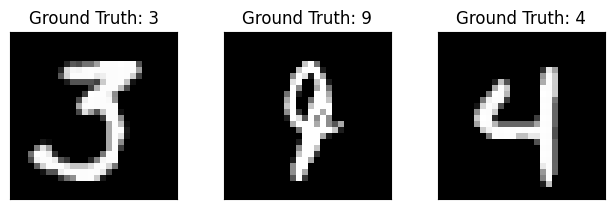

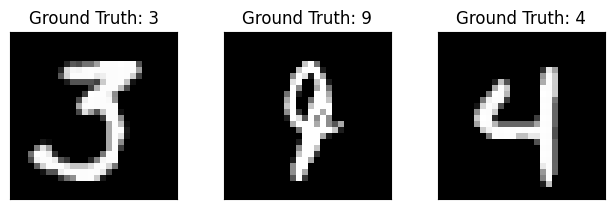

In [25]:
import matplotlib.pyplot as plt

fig = plt.figure()
example_data = example_data.squeeze(1) 
for i in range(3):
  plt.subplot(1,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

### FFNN

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

# Define the feed-forward neural network
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size) 
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.out(x)  # No activation function here
        return x

# Define the model parameters
input_size = 28 * 28  # Flattened input size for MNIST (28x28 images)
hidden_size = 90
output_size = 10  # 10 classes for MNIST (digits 0-9)

# Instantiate the model, loss function, and optimizer
model_ffnn = FFNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
criterion = nn.CrossEntropyLoss()  # Cross Entropy loss for classification
optimizer = optim.Adam(model_ffnn.parameters(), lr=learning_rate)  # Adam optimizer


running_losses_fnn = []
for epoch in range(n_epochs):
    model_ffnn.train()  # Set the model to training mode
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.view(-1, input_size)  # Flatten the inputs
        labels = labels.long()  # Ensure labels are in the correct format
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_ffnn(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    average_loss = running_loss / len(train_loader)  # Calculate average loss
    running_losses_fnn.append(average_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {average_loss:.4f}")

# Evaluation
correct = 0
total = 0
with torch.no_grad():  # Disable gradient calculation for evaluation
    for inputs, labels in train_loader:
        inputs = inputs.view(-1, input_size)  # Flatten the inputs
        labels = labels.long()
        outputs = model_ffnn(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")



Epoch [1/10], Loss: 0.2816
Epoch [2/10], Loss: 0.2081
Epoch [3/10], Loss: 0.1935
Epoch [4/10], Loss: 0.1745
Epoch [5/10], Loss: 0.1757
Epoch [6/10], Loss: 0.1603
Epoch [7/10], Loss: 0.1644
Epoch [8/10], Loss: 0.1552
Epoch [9/10], Loss: 0.1485
Epoch [10/10], Loss: 0.1486
Accuracy: 96.54%


### CNN

In [27]:


# Define the CNN
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=3)  # 1 input channel, 10 output channels
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(10 * 13 * 13, 30)  # Fully connected layer after flattening
        self.fc2 = nn.Linear(30, 10)  # Output layer for 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Convolution + ReLU + MaxPooling
        x = x.view(-1, 10 * 13 * 13)  # Flatten for fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)  # Log softmax for output

# Instantiate the model
model_cnn = CNN()

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross Entropy Loss for classification
optimizer = optim.Adam(model_cnn.parameters(), lr=learning_rate)  # Adam optimizer

running_loss_cnn = []
# Training loop
for epoch in range(n_epochs):
    model_cnn.train()  # Set the model to training mode
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_cnn(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    average_loss = running_loss / len(train_loader)  # Calculate average loss
    running_loss_cnn.append(average_loss)
    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {running_loss / len(train_loader):.4f}")

# Evaluation
correct = 0
total = 0
model_cnn.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation for evaluation
    for inputs, labels in test_loader:  # Evaluate on the test loader
        outputs = model_cnn(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")
print(running_loss_cnn)


Epoch [1/10], Loss: 0.2017
Epoch [2/10], Loss: 0.0879
Epoch [3/10], Loss: 0.0692
Epoch [4/10], Loss: 0.0672
Epoch [5/10], Loss: 0.0635
Epoch [6/10], Loss: 0.0571
Epoch [7/10], Loss: 0.0542
Epoch [8/10], Loss: 0.0549
Epoch [9/10], Loss: 0.0480
Epoch [10/10], Loss: 0.0466
Accuracy: 96.91%
[0.20172845713718773, 0.08791870010226394, 0.06922496548992321, 0.06724970336890032, 0.06348510351834266, 0.05710355513070751, 0.05422361796330528, 0.05491494354191091, 0.047989158377309875, 0.04663831670859702]


[0.2815700926220239, 0.20806574473467304, 0.19352292056396, 0.17446842735612403, 0.17574881945216933, 0.16028059532802338, 0.16437335457773938, 0.15523620848313097, 0.14847084573316904, 0.1485877489277806]
[0.20172845713718773, 0.08791870010226394, 0.06922496548992321, 0.06724970336890032, 0.06348510351834266, 0.05710355513070751, 0.05422361796330528, 0.05491494354191091, 0.047989158377309875, 0.04663831670859702]


Text(0.5, 0, 'Epoch')

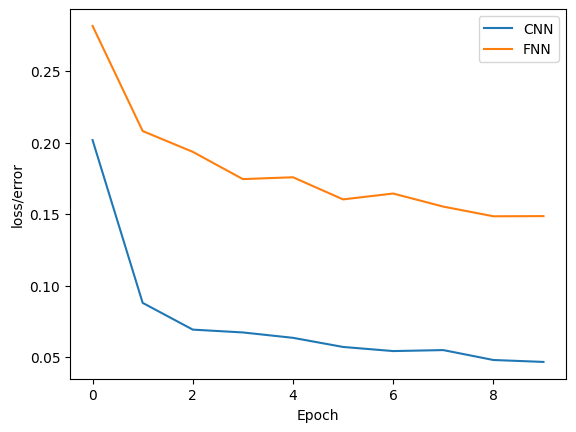

In [28]:
# Graph it out!
print(running_losses_fnn)
print(running_loss_cnn)
plt.plot(range(n_epochs), running_loss_cnn, label="CNN")
plt.plot(range(n_epochs), running_losses_fnn, label = "FNN")
plt.legend()
plt.ylabel("loss/error")
plt.xlabel('Epoch')

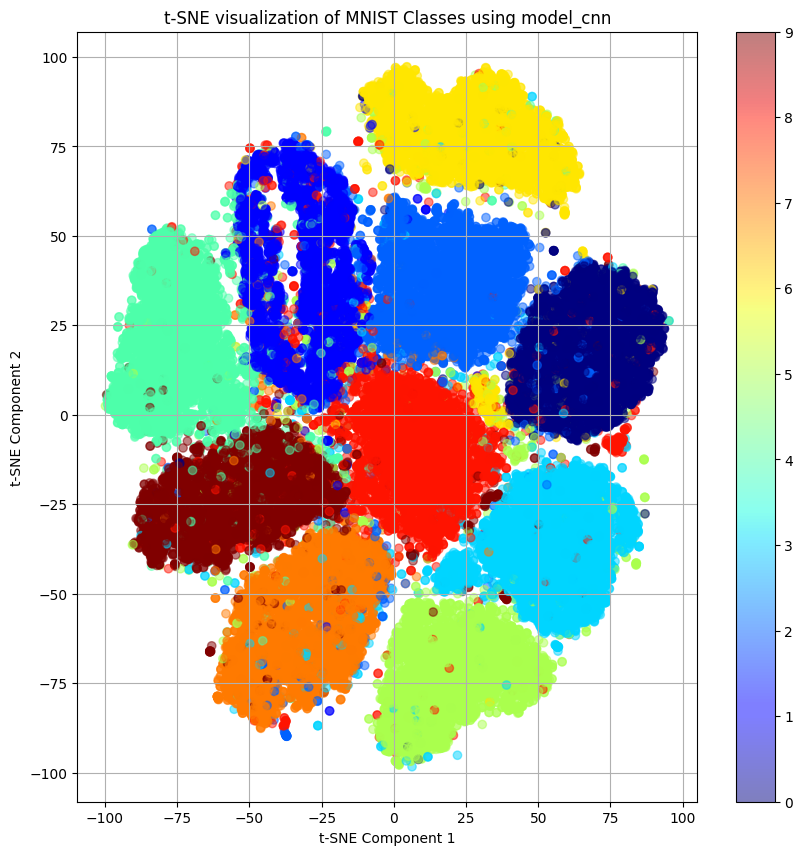

In [29]:
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Use the existing model_cnn for feature extraction
class FeatureExtractorCNN(nn.Module):
    def __init__(self, model):
        super(FeatureExtractorCNN, self).__init__()
        self.model = model

    def forward(self, x):
        x = self.model.pool(F.relu(self.model.conv1(x)))  # Get features from first conv layer and pooling
        x = x.view(-1, 10 * 13 * 13)  # Flatten for fully connected layers
        return x  # Return features before final classification layer

# Instantiate the feature extractor with the existing model_cnn
feature_extractor = FeatureExtractorCNN(model_cnn)
feature_extractor.eval()  # Set model to evaluation mode

# Extract features and labels
features = []
labels = []
with torch.no_grad():  # Disable gradient calculation
    for inputs, label in train_loader:
        output = feature_extractor(inputs)  # Extract features
        features.append(output)
        labels.append(label)

# Concatenate features and labels
features = torch.cat(features).numpy()
labels = torch.cat(labels).numpy()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=0)
features_tsne = tsne.fit_transform(features)

# Create a scatter plot
plt.figure(figsize=(10, 10))
scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, cmap='jet', alpha=0.5)
plt.colorbar(scatter, ticks=range(10))
plt.title('t-SNE visualization of MNIST Classes using model_cnn')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid()
plt.show()


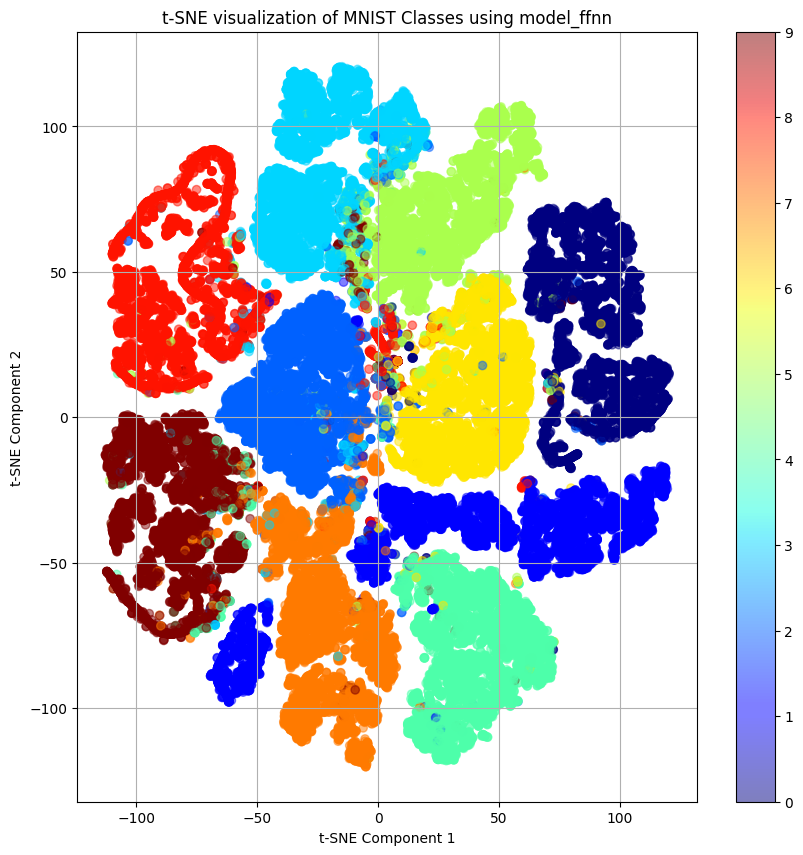

In [30]:
# Define the feature extractor
class FeatureExtractorFFNN(nn.Module):
    def __init__(self, model):
        super(FeatureExtractorFFNN, self).__init__()
        self.model = model

    def forward(self, x):
        x = x.view(-1, input_size)  # Flatten the input
        x = F.relu(self.model.fc1(x))  # Get features from the first fully connected layer
        return x  # Return features before final classification layer

# Assuming model_ffnn is already defined and trained
input_size = 28 * 28  # MNIST input size
hidden_size = 90
output_size = 10

# Instantiate the feature extractor with the existing model_ffnn
feature_extractor = FeatureExtractorFFNN(model_ffnn)
feature_extractor.eval()  # Set model to evaluation mode

# Extract features and labels
features = []
labels = []
with torch.no_grad():  # Disable gradient calculation
    for inputs, label in train_loader:
        output = feature_extractor(inputs)  # Extract features
        features.append(output)
        labels.append(label)

# Concatenate features and labels
features = torch.cat(features).numpy()
labels = torch.cat(labels).numpy()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=0)
features_tsne = tsne.fit_transform(features)

# Create a scatter plot
plt.figure(figsize=(10, 10))
scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, cmap='jet', alpha=0.5)
plt.colorbar(scatter, ticks=range(10))
plt.title('t-SNE visualization of MNIST Classes using model_ffnn')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid()
plt.show()


### Testing on translated data

In [31]:
# Write your code here

# Function to translate images by a certain number of pixels (shifts)
def translate_images(data, shift_x, shift_y):
    translated_data = torch.roll(data, shifts=(shift_x, shift_y), dims=(1, 2))
    return translated_data

# Translate the test set (shift by 2 pixels in both directions)
translated_test_data = translate_images(example_data, shift_x=2, shift_y=2)

# Test FFNN on Translated Test Set
def translated_ffnn(model, translated_data, target):
    model.eval()
    correct = 0
    with torch.no_grad():
        data = translated_data.view(-1, 28*28)  # Flatten the input
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

    accuracy = correct / len(target)
    print(f"FFNN Accuracy on Translated Test Set: {accuracy * 100:.2f}%")
    
# FFNN testing on translated data
translated_ffnn(model_ffnn, translated_test_data, example_targets)




FFNN Accuracy on Translated Test Set: 48.40%


In [36]:


# Test FFNN on Translated Test Set
def translated_ffnn(model, translated_data, target):
    model.eval()
    correct = 0
    with torch.no_grad():
        output = model(translated_data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

    accuracy = correct / len(target)
    print(f"CNN Accuracy on Translated Test Set: {accuracy * 100:.2f}%")

# FFNN testing on translated data
translated_cnn(model_cnn, translated_test_data, example_targets)

CNN Accuracy on Translated Test Set: 71.20%


In [33]:
# Calculate the number of parameters
num_params_ffnn = sum(p.numel() for p in model_ffnn.parameters())
print(f'Number of parameters in FFNN: {num_params_ffnn}')

# Calculate the number of parameters
num_params_cnn = sum(p.numel() for p in model_cnn.parameters())
print(f'Number of parameters in CNN: {num_params_cnn}')

Number of parameters in FFNN: 71560
Number of parameters in CNN: 51140


# Conlcusion
- CNN classification performance is better than FFNN on images
- It used fewer number of parameters than FFNN
